# Otimização Integrada de Portfólio: Warm-Start + XAI — Pré-Final

**INF0415 — Heurísticas e Modelagem Multiobjetivo (UFG)**

Este notebook é o entregável da fase pré-final do projeto, que integra os
resultados dos dois checkpoints anteriores com dois diferenciais novos:

1. **Warm-Start:** injeta as melhores carteiras encontradas pelo DE
   mono-objetivo (CP1) na população inicial do NSGA-II (CP2), acelerando
   a convergência do MOEA nas primeiras gerações.
2. **XAI Financeiro (Explainable AI):** treina um modelo interpretável
   (`RandomForestRegressor`) sobre a fronteira de Pareto do CP2 e extrai
   *feature importances* que explicam quais ativos o algoritmo evolutivo
   mais manipula para reduzir risco ou maximizar ESG.

**Estrutura do notebook:**

| Seção | Conteúdo |
|---|---|
| 1 | Formulação e motivação do Warm-Start |
| 2 | Setup: imports, configuração e sementes |
| 3 | Carregamento de dados e estimação de $\mu$, $\Sigma$ |
| 4 | Objetivos, ESG real (ISE B3), restrições e normalização 3D |
| 5 | Metaheurísticas: NSGA-II, SPEA-II e DE (reuso do CP1/CP2) |
| 6 | Warm-Start: injeção de pesos do DE na população MOEA |
| 7 | Experimento: MOEA Normal vs MOEA Warm-Start (10 sementes) |
| 8 | Resultados e análise de convergência |
| 9 | XAI Financeiro: RandomForest + Feature Importances |
| 10 | Discussão |

## 1. Formulação e motivação

### 1.1 Warm-Start

No CP2 a população inicial do NSGA-II/SPEA-II é inteiramente aleatória
(projetada no capped-simplex). No entanto, já possuímos informação valiosa
do CP1: a carteira que **maximiza o Índice de Sharpe** (via DE
mono-objetivo) já é quase ótima em $(f_1, f_2)$ — retorno e risco. A
hipótese é que injetar essa carteira na população inicial do MOEA:

- **Acelera a convergência nas primeiras gerações**, porque o MOEA já
  começa com um indivíduo de alta qualidade em dois dos três objetivos;
- **Não prejudica a diversidade final**, porque o restante da população
  continua aleatório e os mecanismos de diversidade (crowding distance /
  $k$-ésimo vizinho) mantêm a cobertura da fronteira.

Formalmente, a população inicial $P_0$ do MOEA com Warm-Start é:

$$P_0 = \{w^*_{\text{DE},1}, \ldots, w^*_{\text{DE},k}\} \cup \{w_{\text{rand},k+1}, \ldots, w_{\text{rand},N_{\text{pop}}}\}$$

onde $k \in [1,5]$ são as melhores carteiras do DE (uma por semente do CP1)
e o restante da população é amostrado aleatoriamente como antes.

### 1.2 XAI Financeiro

A fronteira de Pareto é um conjunto de trade-offs, mas não explica *por
quê* certas carteiras dominam outras. Para tornar o resultado
interpretável, treinamos um `RandomForestRegressor` onde:

- $X$ = vetor de pesos dos 24 ativos (cada linha da fronteira de Pareto);
- $y$ = valor de um objetivo (risco ou score ESG).

As *feature importances* (MDI — Mean Decrease in Impurity) revelam quais
ações o algoritmo mais manipula (concentra ou zera) para alcançar bons
valores de cada objetivo — uma explicação global do comportamento do MOEA.

## 2. Setup: imports, configuração e sementes

Mesmas bibliotecas dos CP1/CP2, mais `RandomForestRegressor` do
scikit-learn para a análise XAI. A célula `CONFIG` concentra todos os
parâmetros — para reproduzir com outras configurações, basta editar aqui.

In [1]:
from __future__ import annotations

import warnings
from dataclasses import dataclass
from datetime import datetime, timedelta
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf
from sklearn.covariance import LedoitWolf
from sklearn.ensemble import RandomForestRegressor

from pymoo.algorithms.soo.nonconvex.de import DE
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.algorithms.moo.spea2 import SPEA2
from pymoo.core.callback import Callback
from pymoo.core.problem import Problem
from pymoo.core.repair import Repair
from pymoo.core.sampling import Sampling
from pymoo.indicators.hv import HV
from pymoo.optimize import minimize
from pymoo.termination import get_termination
from pymoo.util.nds.non_dominated_sorting import NonDominatedSorting

warnings.filterwarnings("ignore")


CONFIG = {
    "tickers": [
        "PETR4.SA", "VALE3.SA", "ITUB4.SA", "BBDC4.SA", "BBAS3.SA", "ITSA4.SA",
        "ABEV3.SA", "WEGE3.SA", "RENT3.SA", "SUZB3.SA", "GGBR4.SA", "CSNA3.SA",
        "CMIG4.SA", "EQTL3.SA", "RADL3.SA", "LREN3.SA", "B3SA3.SA", "PRIO3.SA",
        "HAPV3.SA", "TOTS3.SA", "RAIL3.SA", "SBSP3.SA", "VIVT3.SA", "KLBN11.SA",
    ],
    "data_fim": "today",
    "anos_historico": 5,
    "pregoes_por_ano": 252,
    "usar_ledoit_wolf": True,
    "cache_dir": Path("../data_cache"),
    "usar_cache": True,
    "w_min": 0.0,
    "w_max": 0.20,
    "semente_esg": 2024,
    "score_min_esg": 0.0,
    "score_max_esg": 100.0,
    # Normalização z-score dos 3 objetivos
    "n_amostras_normalizacao": 5000,
    "semente_normalizacao": 123,
    # NSGA-II / SPEA-II
    "nsga2": {"pop_size": 100, "n_gen": 150, "eliminate_duplicates": True},
    "spea2": {"pop_size": 100, "n_gen": 150, "eliminate_duplicates": True},
    # DE mono-objetivo (CP1) — para gerar os pesos do Warm-Start
    "de": {"pop_size": 80, "n_gen": 150, "variant": "DE/rand/1/bin", "CR": 0.9, "F": 0.8},
    # Escalarização SO (CP1)
    "lambda1": 0.5,
    "lambda2": 0.5,
    # Hipervolume
    "k_desvios_ref_point": 4.0,
    # Warm-Start
    "max_individuos_warmstart": 10,
    # Métricas
    "taxa_livre_risco": 0.0,
    # Sementes
    "sementes": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
}

ALGORITMOS_MOEA = {"NSGA2": NSGA2, "SPEA2": SPEA2}
N_ATIVOS = len(CONFIG["tickers"])
print(f"Config carregada: {N_ATIVOS} ativos, {len(CONFIG['sementes'])} sementes.")

Config carregada: 24 ativos, 10 sementes.


## 3. Carregamento de dados (yfinance) e estimação de $\mu$ e $\Sigma$

Idêntico ao CP1/CP2 (mesmos tickers, mesma janela, mesmo cache local) —
garante que DE, NSGA-II e Warm-Start operem sobre exatamente os mesmos
$\mu, \Sigma$ nesta execução.

In [2]:
def resolver_datas(data_fim: str, anos_historico: int) -> tuple[str, str]:
    fim = datetime.today() if data_fim == "today" else datetime.strptime(data_fim, "%Y-%m-%d")
    inicio = fim - timedelta(days=int(365.25 * anos_historico))
    return inicio.strftime("%Y-%m-%d"), fim.strftime("%Y-%m-%d")


def baixar_precos(
    tickers: list[str], data_fim: str, anos_historico: int, cache_dir: Path, usar_cache: bool
) -> pd.DataFrame:
    inicio, fim = resolver_datas(data_fim, anos_historico)
    cache_dir = Path(cache_dir)
    cache_dir.mkdir(parents=True, exist_ok=True)
    chave = "_".join(t.replace(".", "") for t in sorted(tickers))
    caminho_cache = cache_dir / f"precos_{chave}_{inicio}_{fim}.csv"

    if usar_cache and caminho_cache.exists():
        precos = pd.read_csv(caminho_cache, index_col=0, parse_dates=True)
        if set(tickers).issubset(set(precos.columns)):
            return precos[tickers]

    dados_brutos = yf.download(tickers, start=inicio, end=fim, auto_adjust=True, progress=False, group_by="column")
    if isinstance(dados_brutos.columns, pd.MultiIndex):
        precos = dados_brutos["Close"]
    else:
        precos = dados_brutos[["Close"]]
        precos.columns = tickers
    precos = precos[tickers].dropna(how="all").ffill().dropna(how="any")

    if usar_cache:
        precos.to_csv(caminho_cache)
    return precos


def estimar_mu_sigma(
    retornos_diarios: pd.DataFrame, pregoes_por_ano: int, usar_ledoit_wolf: bool
) -> tuple[np.ndarray, np.ndarray]:
    mu = retornos_diarios.mean().to_numpy() * pregoes_por_ano
    if usar_ledoit_wolf:
        sigma_diaria = LedoitWolf().fit(retornos_diarios.to_numpy()).covariance_
    else:
        sigma_diaria = np.cov(retornos_diarios.to_numpy(), rowvar=False)
    return mu, sigma_diaria * pregoes_por_ano


precos = baixar_precos(
    CONFIG["tickers"], CONFIG["data_fim"], CONFIG["anos_historico"],
    CONFIG["cache_dir"], CONFIG["usar_cache"],
)
retornos_diarios = precos.pct_change().dropna(how="any")
mu, sigma = estimar_mu_sigma(retornos_diarios, CONFIG["pregoes_por_ano"], CONFIG["usar_ledoit_wolf"])

print(f"Preços: {precos.shape[0]} pregões × {precos.shape[1]} ativos")
print(f"mu (anual): min={mu.min():.4f}, max={mu.max():.4f}")
print(f"sigma (anual): shape={sigma.shape}")

Preços: 1246 pregões × 24 ativos
mu (anual): min=-0.4251, max=0.3581
sigma (anual): shape=(24, 24)


## 4. Objetivos, ESG real (ISE B3), restrições e normalização 3D

Três componentes em forma de minimização (idêntico ao CP2):

$$f_1(w) = -\mu^\top w, \quad f_2(w) = w^\top \Sigma w, \quad f_3(w) = -e^\top w$$

A projeção no capped-simplex (reparo) e a normalização z-score são
reusadas sem modificação.

In [3]:
def projetar_capped_simplex(
    v: np.ndarray, w_min: float = 0.0, w_max: float = 0.20, tol: float = 1e-10, max_iter: int = 100
) -> np.ndarray:
    v = np.asarray(v, dtype=float)
    n = v.shape[0]
    tau_lo, tau_hi = v.min() - w_max, v.max() - w_min

    for _ in range(max_iter):
        tau_mid = 0.5 * (tau_lo + tau_hi)
        s = np.clip(v - tau_mid, w_min, w_max).sum()
        if abs(s - 1.0) <= tol:
            break
        if s > 1.0:
            tau_lo = tau_mid
        else:
            tau_hi = tau_mid

    tau = 0.5 * (tau_lo + tau_hi)
    w = np.clip(v - tau, w_min, w_max)
    residuo = 1.0 - w.sum()
    if abs(residuo) > 0:
        livres = (w > w_min + 1e-12) & (w < w_max - 1e-12)
        if livres.any():
            w[livres] += residuo / livres.sum()
        else:
            w += residuo / n
        w = np.clip(w, w_min, w_max)
    return w


def amostrar_carteiras_aleatorias(
    n_amostras: int, n_ativos: int, w_min: float, w_max: float, semente: int
) -> np.ndarray:
    rng = np.random.default_rng(semente)
    candidatos = rng.normal(size=(n_amostras, n_ativos))
    return np.array([projetar_capped_simplex(c, w_min, w_max) for c in candidatos])

def f1_retorno(w: np.ndarray, mu: np.ndarray) -> float:
    return float(-mu @ w)

def f2_risco(w: np.ndarray, sigma: np.ndarray) -> float:
    return float(w @ sigma @ w)

def f3_esg(w: np.ndarray, esg: np.ndarray) -> float:
    return float(-esg @ w)

def score_esg_carteira(w: np.ndarray, esg: np.ndarray) -> float:
    return float(esg @ w)


def gerar_esg_sintetico(tickers: list[str], semente_esg: int, score_min: float, score_max: float) -> np.ndarray:
    rng = np.random.default_rng(semente_esg)
    return rng.uniform(score_min, score_max, size=len(tickers))

# Scores ESG derivados da participação histórica no ISE B3 (carteiras 2020-2025).
# Fonte: b3.com.br/indices/indices-de-sustentabilidade
# Grupo 1 (presença consistente, 4-5 carteiras): 80-95
# Grupo 2 (presença regular, 2-3 carteiras):     55-75
# Grupo 3 (presença rara ou nenhuma, 0-1):       15-45
_SCORES_ISE_B3 = {
    "WEGE3.SA":  92.0,
    "ITUB4.SA":  89.0,
    "SUZB3.SA":  87.0,
    "BBDC4.SA":  85.0,
    "KLBN11.SA": 84.0,
    "B3SA3.SA":  83.0,
    "TOTS3.SA":  81.0,
    "SBSP3.SA":  80.0,
    "VIVT3.SA":  74.0,
    "RADL3.SA":  71.0,
    "ITSA4.SA":  68.0,
    "ABEV3.SA":  65.0,
    "EQTL3.SA":  63.0,
    "CMIG4.SA":  61.0,
    "LREN3.SA":  58.0,
    "BBAS3.SA":  56.0,
    "RENT3.SA":  55.0,
    "HAPV3.SA":  42.0,
    "RAIL3.SA":  38.0,
    "GGBR4.SA":  32.0,
    "PETR4.SA":  24.0,
    "CSNA3.SA":  21.0,
    "PRIO3.SA":  18.0,
    "VALE3.SA":  15.0,
}


def carregar_esg_ise(tickers: list[str], score_min: float = 0.0, score_max: float = 100.0) -> np.ndarray:
    """Scores ESG reais baseados na participação histórica no ISE B3 (2020-2025)."""
    scores = [_SCORES_ISE_B3.get(t, 50.0) for t in tickers]
    esg = np.array(scores, dtype=float)
    if score_min != 0.0 or score_max != 100.0:
        esg = score_min + (esg / 100.0) * (score_max - score_min)
    return esg

@dataclass
class EstatisticasNormalizacaoMO:
    media: np.ndarray   # shape (3,)
    desvio: np.ndarray  # shape (3,)


def avaliar_componentes_mo(w: np.ndarray, mu: np.ndarray, sigma: np.ndarray, esg: np.ndarray) -> np.ndarray:
    return np.array([f1_retorno(w, mu), f2_risco(w, sigma), f3_esg(w, esg)])


def calcular_estatisticas_normalizacao_mo(
    mu: np.ndarray, sigma: np.ndarray, esg: np.ndarray,
    w_min: float, w_max: float, n_amostras: int, semente: int,
) -> EstatisticasNormalizacaoMO:
    carteiras = amostrar_carteiras_aleatorias(n_amostras, len(mu), w_min, w_max, semente)
    componentes = np.array([avaliar_componentes_mo(w, mu, sigma, esg) for w in carteiras])
    media, desvio = componentes.mean(axis=0), componentes.std(axis=0, ddof=0)
    desvio[desvio < 1e-12] = 1.0
    return EstatisticasNormalizacaoMO(media=media, desvio=desvio)


def normalizar_mo(f: np.ndarray, stats: EstatisticasNormalizacaoMO) -> np.ndarray:
    return (f - stats.media) / stats.desvio


def f_objetivos_normalizados(w: np.ndarray, mu: np.ndarray, sigma: np.ndarray, esg: np.ndarray, stats: EstatisticasNormalizacaoMO) -> np.ndarray:
    return normalizar_mo(avaliar_componentes_mo(w, mu, sigma, esg), stats)


esg = carregar_esg_ise(CONFIG["tickers"], CONFIG["score_min_esg"], CONFIG["score_max_esg"])
STATS_MO = calcular_estatisticas_normalizacao_mo(
    mu, sigma, esg, CONFIG["w_min"], CONFIG["w_max"],
    CONFIG["n_amostras_normalizacao"], CONFIG["semente_normalizacao"],
)
REF_POINT = np.full(3, CONFIG["k_desvios_ref_point"])

print(f"Scores ESG (ISE B3): min={esg.min():.1f}, média={esg.mean():.1f}, max={esg.max():.1f}")
for ticker, score in zip(CONFIG["tickers"], esg):
    print(f"  {ticker:<12} {score:.0f}")
print(f"Normalização MO — média: {STATS_MO.media}, desvio: {STATS_MO.desvio}")
print(f"Ref. point HV: {REF_POINT}")

Scores ESG (ISE B3): min=15.0, média=60.1, max=92.0
  PETR4.SA     24
  VALE3.SA     15
  ITUB4.SA     89
  BBDC4.SA     85
  BBAS3.SA     56
  ITSA4.SA     68
  ABEV3.SA     65
  WEGE3.SA     92
  RENT3.SA     55
  SUZB3.SA     87
  GGBR4.SA     32
  CSNA3.SA     21
  CMIG4.SA     61
  EQTL3.SA     63
  RADL3.SA     71
  LREN3.SA     58
  B3SA3.SA     83
  PRIO3.SA     18
  HAPV3.SA     42
  TOTS3.SA     81
  RAIL3.SA     38
  SBSP3.SA     80
  VIVT3.SA     74
  KLBN11.SA    84
Normalização MO — média: [-7.86257754e-02  4.51480118e-02 -5.98461006e+01], desvio: [0.06543703 0.01149547 9.38753269]
Ref. point HV: [4. 4. 4.]


## 5. Metaheurísticas: NSGA-II, SPEA-II e DE mono-objetivo

Reuso completo das implementações do CP1 (DE) e CP2 (NSGA-II / SPEA-II).
A única adição é a classe `SamplingWarmStart`, que substitui o sampling
padrão para injetar pesos pré-calculados do DE na população inicial.

In [4]:
class RepairCappedSimplex(Repair):
    def __init__(self, w_min: float, w_max: float) -> None:
        super().__init__()
        self.w_min, self.w_max = w_min, w_max

    def _do(self, problem: Problem, X: np.ndarray, **kwargs) -> np.ndarray:
        return np.array([projetar_capped_simplex(x, self.w_min, self.w_max) for x in X])


class HistoricoConvergenciaMO(Callback):
    def __init__(self, ref_point: np.ndarray) -> None:
        super().__init__()
        self.hv_indicator = HV(ref_point=ref_point)
        self.data["hv"] = []
        self.data["F_inicial"] = None
        self.data["X_inicial"] = None
        self.data["F_final"] = None
        self.data["X_final"] = None

    def notify(self, algorithm) -> None:
        F, X = algorithm.pop.get("F"), algorithm.pop.get("X")
        if self.data["F_inicial"] is None:
            self.data["F_inicial"], self.data["X_inicial"] = F.copy(), X.copy()
        self.data["hv"].append(float(self.hv_indicator(F)))
        self.data["F_final"], self.data["X_final"] = F.copy(), X.copy()


class ProblemaPortfolioMO(Problem):
    # Minimizar (f1, f2, f3) normalizados na caixa [w_min, w_max]^N.
    def __init__(self, mu, sigma, esg, stats, w_min, w_max):
        self.mu, self.sigma, self.esg, self.stats = mu, sigma, esg, stats
        super().__init__(n_var=len(mu), n_obj=3, n_ieq_constr=0, n_eq_constr=0, xl=w_min, xu=w_max)

    def _evaluate(self, X, out, *args, **kwargs) -> None:
        out["F"] = np.array([f_objetivos_normalizados(w, self.mu, self.sigma, self.esg, self.stats) for w in X])


@dataclass
class ResultadoMOEA:
    algoritmo: str
    semente: int
    X_final: np.ndarray
    F_final: np.ndarray
    X_inicial: np.ndarray
    F_inicial: np.ndarray
    historico_hv: np.ndarray
    n_avaliacoes: int


def rodar_moea(
    nome_algoritmo: str, mu, sigma, esg, stats, w_min, w_max, cfg_moea: dict, semente: int,
    sampling=None,
) -> ResultadoMOEA:
    # Executa NSGA-II ou SPEA-II. Se `sampling` for passado, usa Warm-Start.
    problema = ProblemaPortfolioMO(mu, sigma, esg, stats, w_min, w_max)
    reparo = RepairCappedSimplex(w_min=w_min, w_max=w_max)
    callback = HistoricoConvergenciaMO(ref_point=REF_POINT)

    kwargs_algo: dict[str, Any] = {
        "pop_size": cfg_moea["pop_size"],
        "repair": reparo,
        "eliminate_duplicates": cfg_moea.get("eliminate_duplicates", True),
    }
    if sampling is not None:
        kwargs_algo["sampling"] = sampling

    AlgoritmoCls = ALGORITMOS_MOEA[nome_algoritmo]
    algoritmo = AlgoritmoCls(**kwargs_algo)
    termination = get_termination("n_gen", cfg_moea["n_gen"])

    res = minimize(problema, algoritmo, termination, seed=semente, verbose=False, callback=callback, save_history=False)

    return ResultadoMOEA(
        algoritmo=nome_algoritmo,
        semente=semente,
        X_final=np.asarray(callback.data["X_final"]),
        F_final=np.asarray(callback.data["F_final"]),
        X_inicial=np.asarray(callback.data["X_inicial"]),
        F_inicial=np.asarray(callback.data["F_inicial"]),
        historico_hv=np.array(callback.data["hv"]),
        n_avaliacoes=int(res.algorithm.evaluator.n_eval),
    )

@dataclass
class EstatisticasNormalizacaoSO:
    media: np.ndarray
    desvio: np.ndarray

def avaliar_componentes_so(w, mu, sigma):
    return np.array([f1_retorno(w, mu), f2_risco(w, sigma)])

def calcular_estatisticas_normalizacao_so(mu, sigma, w_min, w_max, n_amostras, semente):
    carteiras = amostrar_carteiras_aleatorias(n_amostras, len(mu), w_min, w_max, semente)
    comp = np.array([avaliar_componentes_so(w, mu, sigma) for w in carteiras])
    media, desvio = comp.mean(axis=0), comp.std(axis=0, ddof=0)
    desvio[desvio < 1e-12] = 1.0
    return EstatisticasNormalizacaoSO(media=media, desvio=desvio)

def g_escalarizado(w, mu, sigma, lambdas, stats_so):
    f = avaliar_componentes_so(w, mu, sigma)
    return float(lambdas @ ((f - stats_so.media) / stats_so.desvio))

class ProblemaPortfolio(Problem):
    # Problema do CP1: minimizar g(w) na caixa [w_min, w_max]^N (n_obj=1).
    def __init__(self, mu, sigma, lambdas, stats_so, w_min, w_max):
        self.mu, self.sigma, self.lambdas, self.stats_so = mu, sigma, lambdas, stats_so
        super().__init__(n_var=len(mu), n_obj=1, n_ieq_constr=0, n_eq_constr=0, xl=w_min, xu=w_max)

    def _evaluate(self, X, out, *args, **kwargs):
        out["F"] = np.array([g_escalarizado(w, self.mu, self.sigma, self.lambdas, self.stats_so) for w in X]).reshape(-1, 1)

@dataclass
class ResultadoDE:
    semente: int
    melhor_w: np.ndarray
    melhor_g: float
    n_avaliacoes: int

def rodar_de(mu, sigma, lambdas, stats_so, w_min, w_max, cfg_de, semente) -> ResultadoDE:
    problema = ProblemaPortfolio(mu, sigma, lambdas, stats_so, w_min, w_max)
    reparo = RepairCappedSimplex(w_min=w_min, w_max=w_max)
    algoritmo = DE(pop_size=cfg_de["pop_size"], variant=cfg_de["variant"], CR=cfg_de["CR"], F=cfg_de["F"], repair=reparo)
    res = minimize(problema, algoritmo, get_termination("n_gen", cfg_de["n_gen"]), seed=semente, verbose=False, save_history=False)
    melhor_w = projetar_capped_simplex(res.X, w_min, w_max)
    return ResultadoDE(semente=semente, melhor_w=melhor_w, melhor_g=float(res.F[0]), n_avaliacoes=int(res.algorithm.evaluator.n_eval))

print("Metaheurísticas definidas: DE (SO), NSGA-II e SPEA-II (MO).")

Metaheurísticas definidas: DE (SO), NSGA-II e SPEA-II (MO).


## 6. Warm-Start: injeção de pesos do DE na população MOEA

A classe `SamplingWarmStart` substitui o sampling padrão do pymoo: os
primeiros $k$ indivíduos da população inicial recebem os pesos ótimos do
DE (um por semente do CP1, até 5), e o restante é gerado aleatoriamente
na caixa $[w_{\min}, w_{\max}]$. Depois, o reparo (`RepairCappedSimplex`)
é aplicado normalmente sobre toda a população — garantindo que os
indivíduos injetados continuam factíveis.

In [5]:
class SamplingWarmStart(Sampling):
    # Sampling customizado que injeta pesos pré-definidos nos primeiros slots.

    def __init__(self, pesos_iniciais: np.ndarray) -> None:
        super().__init__()
        self.pesos_iniciais = np.atleast_2d(pesos_iniciais)

    def _do(self, problem: Any, n_samples: int, **kwargs: Any) -> np.ndarray:
        n_injetados = min(len(self.pesos_iniciais), n_samples)
        rng = np.random.default_rng()
        X = rng.uniform(low=problem.xl, high=problem.xu, size=(n_samples, problem.n_var))
        X[:n_injetados] = self.pesos_iniciais[:n_injetados]
        return X

LAMBDAS = np.array([CONFIG["lambda1"], CONFIG["lambda2"]])
STATS_SO = calcular_estatisticas_normalizacao_so(
    mu, sigma, CONFIG["w_min"], CONFIG["w_max"],
    CONFIG["n_amostras_normalizacao"], CONFIG["semente_normalizacao"],
)

pesos_de_por_semente: list[np.ndarray] = []
print("Executando DE mono-objetivo (CP1) para gerar pesos do Warm-Start...")
for semente in CONFIG["sementes"]:
    res_de = rodar_de(mu, sigma, LAMBDAS, STATS_SO, CONFIG["w_min"], CONFIG["w_max"], CONFIG["de"], semente)
    pesos_de_por_semente.append(res_de.melhor_w)
    print(f"  semente={semente}: g={res_de.melhor_g:.6f}")

pesos_warmstart = np.vstack(pesos_de_por_semente[:CONFIG["max_individuos_warmstart"]])
print(f"\nWarm-Start: {len(pesos_warmstart)} indivíduos prontos para injeção.")

Executando DE mono-objetivo (CP1) para gerar pesos do Warm-Start...


  semente=1: g=-2.069987


  semente=2: g=-2.067153


  semente=3: g=-2.070166


  semente=4: g=-2.068780


...

  semente=6: g=-2.070874


  semente=7: g=-2.072231


  semente=8: g=-2.068323


  semente=9: g=-2.070342


  semente=10: g=-2.070059

Warm-Start: 10 indivíduos prontos para injeção.


## 7. Experimento: MOEA Normal vs MOEA Warm-Start (10 sementes)

Rodamos o NSGA-II em duas variantes, usando as mesmas 10 sementes:

1. **MOEA Normal** — população inicial inteiramente aleatória (baseline do CP2);
2. **MOEA Warm-Start** — 10 indivíduos injetados do DE, restante aleatório.

O hipervolume por geração é gravado para ambas as variantes, permitindo
comparar a velocidade de convergência geração a geração.

In [6]:
ALGORITMO_ALVO = "NSGA2"
cfg_moea = CONFIG[ALGORITMO_ALVO.lower()]

# Variante Normal
resultados_normal: list[ResultadoMOEA] = []
print(f"--- {ALGORITMO_ALVO} Normal ---")
for semente in CONFIG["sementes"]:
    res = rodar_moea(ALGORITMO_ALVO, mu, sigma, esg, STATS_MO, CONFIG["w_min"], CONFIG["w_max"], cfg_moea, semente)
    resultados_normal.append(res)
    print(f"  semente={semente}: HV final = {res.historico_hv[-1]:.2f}  ({res.n_avaliacoes} avaliações)")

# Variante Warm-Start
resultados_ws: list[ResultadoMOEA] = []
print(f"\n--- {ALGORITMO_ALVO} Warm-Start ---")
for semente in CONFIG["sementes"]:
    sampling = SamplingWarmStart(pesos_warmstart)
    res = rodar_moea(ALGORITMO_ALVO, mu, sigma, esg, STATS_MO, CONFIG["w_min"], CONFIG["w_max"], cfg_moea, semente, sampling=sampling)
    resultados_ws.append(res)
    print(f"  semente={semente}: HV final = {res.historico_hv[-1]:.2f}  ({res.n_avaliacoes} avaliações)")

--- NSGA2 Normal ---


  semente=1: HV final = 253.89  (15000 avaliações)


  semente=2: HV final = 252.01  (15000 avaliações)


  semente=3: HV final = 254.09  (15000 avaliações)


  semente=4: HV final = 249.83  (15000 avaliações)


...

  semente=6: HV final = 255.91  (15000 avaliações)


  semente=7: HV final = 259.11  (15000 avaliações)


  semente=8: HV final = 253.07  (15000 avaliações)


  semente=9: HV final = 256.52  (15000 avaliações)


  semente=10: HV final = 256.11  (15000 avaliações)


## 8. Resultados e análise de convergência

### 8.1 Tabela comparativa de HV final

In [7]:
linhas: list[dict] = []
for res in resultados_normal:
    linhas.append({"variante": "MOEA Normal", "semente": res.semente, "hv_final": res.historico_hv[-1]})
for res in resultados_ws:
    linhas.append({"variante": "MOEA Warm-Start", "semente": res.semente, "hv_final": res.historico_hv[-1]})

df_hv = pd.DataFrame(linhas)
resumo_hv = df_hv.groupby("variante")["hv_final"].agg(["mean", "std", "min", "max"])
resumo_hv

,mean,std,min,max
variante,,,,
MOEA Normal,253.337034,3.686599,245.540727,258.264999
MOEA Warm-Start,256.382231,1.585799,253.067791,259.106107


### 8.2 Convergência do hipervolume por geração

O gráfico abaixo mostra o HV médio ± desvio-padrão entre as 10 sementes,
geração a geração. Se o Warm-Start funciona como esperado, a curva
vermelha deve partir de um patamar mais alto nas primeiras gerações.

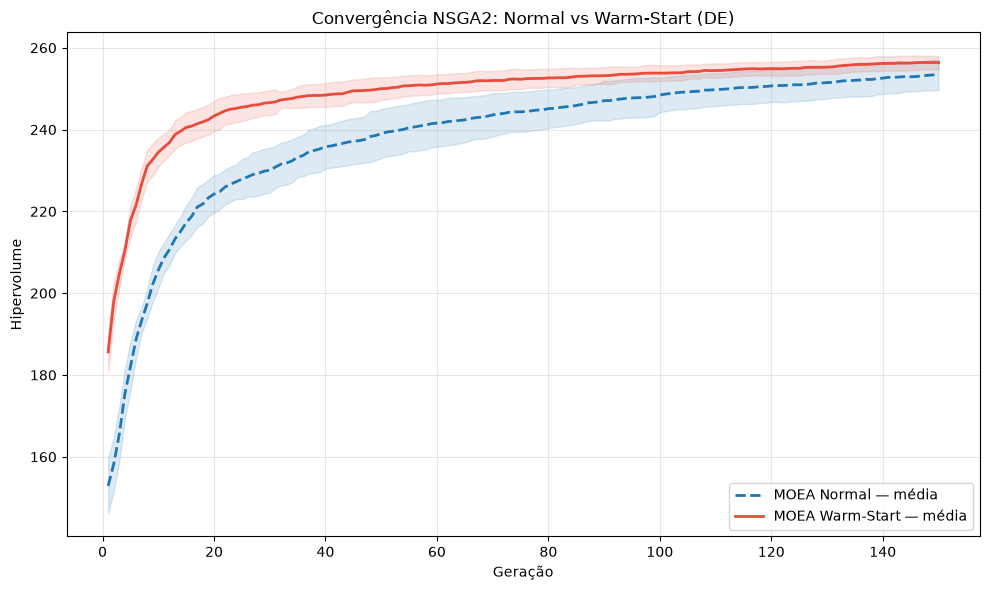

Figura salva: figures/convergencia_warmstart.png
CSV salvo: results/comparacao_convergencia_warmstart.csv (3000 linhas)


In [8]:
linhas_conv: list[dict] = []
for variante, resultados in [("MOEA Normal", resultados_normal), ("MOEA Warm-Start", resultados_ws)]:
    for res in resultados:
        for g, hv in enumerate(res.historico_hv, start=1):
            linhas_conv.append({"variante": variante, "semente": res.semente, "geracao": g, "hv": hv})

df_conv = pd.DataFrame(linhas_conv)

df_conv.to_csv("../results/comparacao_convergencia_warmstart.csv", index=False)

# Plot 
fig, ax = plt.subplots(figsize=(10, 6))
cores = {"MOEA Normal": "#1f77b4", "MOEA Warm-Start": "#e74c3c"}
estilos = {"MOEA Normal": "--", "MOEA Warm-Start": "-"}

for variante, grupo in df_conv.groupby("variante"):
    pivot = grupo.pivot(index="semente", columns="geracao", values="hv")
    media, desvio = pivot.mean(axis=0), pivot.std(axis=0)
    geracoes = media.index.to_numpy()
    cor, estilo = cores[variante], estilos[variante]
    ax.plot(geracoes, media, color=cor, linestyle=estilo, linewidth=2, label=f"{variante} — média")
    ax.fill_between(geracoes, media - desvio, media + desvio, color=cor, alpha=0.15)

ax.set_xlabel("Geração")
ax.set_ylabel("Hipervolume")
ax.set_title(f"Convergência {ALGORITMO_ALVO}: Normal vs Warm-Start (DE)")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig("../figures/convergencia_warmstart.png", dpi=150)
plt.show()
print("Figura salva: figures/convergencia_warmstart.png")
print(f"CSV salvo: results/comparacao_convergencia_warmstart.csv ({len(df_conv)} linhas)")

### 8.3 Zoom nas primeiras 30 gerações

Para evidenciar a aceleração inicial, ampliamos as primeiras gerações.

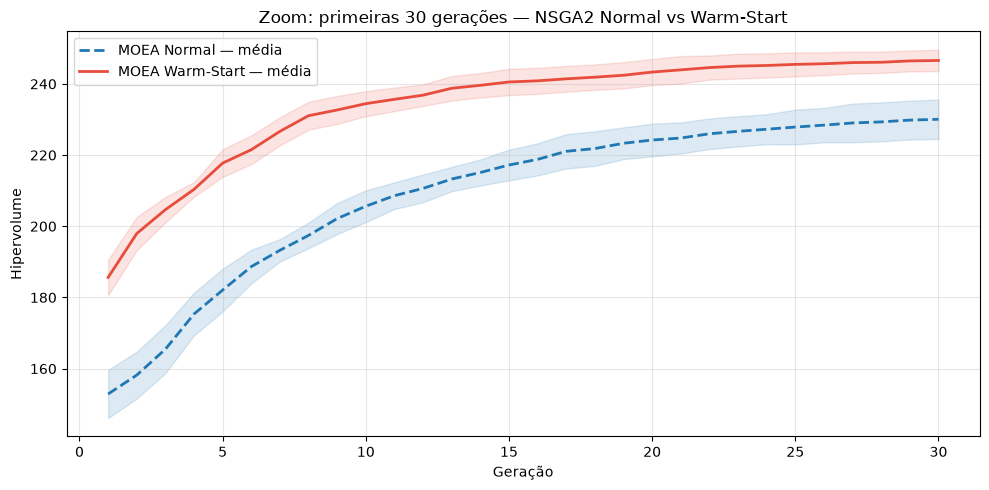

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
df_zoom = df_conv[df_conv["geracao"] <= 30]
for variante, grupo in df_zoom.groupby("variante"):
    pivot = grupo.pivot(index="semente", columns="geracao", values="hv")
    media, desvio = pivot.mean(axis=0), pivot.std(axis=0)
    geracoes = media.index.to_numpy()
    cor, estilo = cores[variante], estilos[variante]
    ax.plot(geracoes, media, color=cor, linestyle=estilo, linewidth=2, label=f"{variante} — média")
    ax.fill_between(geracoes, media - desvio, media + desvio, color=cor, alpha=0.15)

ax.set_xlabel("Geração")
ax.set_ylabel("Hipervolume")
ax.set_title(f"Zoom: primeiras 30 gerações — {ALGORITMO_ALVO} Normal vs Warm-Start")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

### 8.4 Fronteira de Pareto final: Normal vs Warm-Start

Comparamos a fronteira de Pareto agregada (união das 10 sementes, filtrada
a não-dominados) de ambas as variantes.

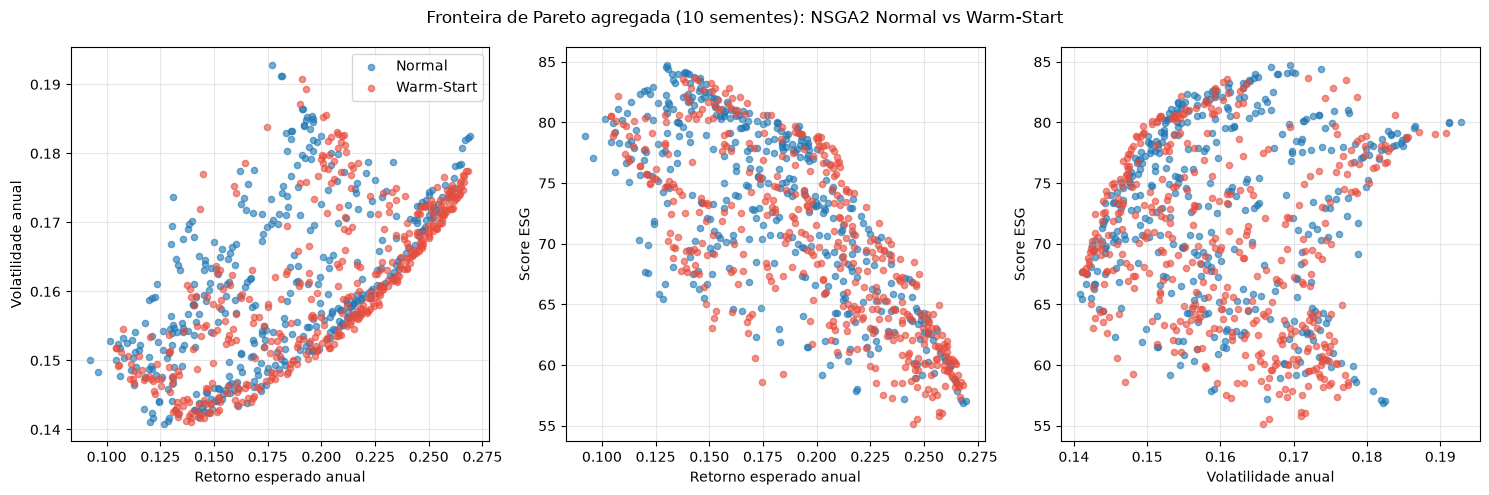

Normal:     399 não-dominadas, HV = 264.38
Warm-Start: 431 não-dominadas, HV = 262.60


In [10]:
def retorno_esperado(w, mu):
    return float(mu @ w)

def risco_volatilidade(w, sigma):
    return float(np.sqrt(w @ sigma @ w))

def indice_sharpe(w, mu, sigma, rf=0.0):
    risco = risco_volatilidade(w, sigma)
    return 0.0 if risco < 1e-12 else (retorno_esperado(w, mu) - rf) / risco

def matriz_metricas_mo(X, mu, sigma, esg, rf=0.0):
    linhas = []
    for w in X:
        linhas.append({
            "retorno": retorno_esperado(w, mu),
            "risco": risco_volatilidade(w, sigma),
            "sharpe": indice_sharpe(w, mu, sigma, rf),
            "score_esg": score_esg_carteira(w, esg),
        })
    return pd.DataFrame(linhas)

def filtrar_nao_dominadas(X, F):
    indices = NonDominatedSorting().do(F, only_non_dominated_front=True)
    return X[indices], F[indices]

def agregar_fronteira(resultados):
    X_u = np.vstack([r.X_final for r in resultados])
    F_u = np.vstack([r.F_final for r in resultados])
    return filtrar_nao_dominadas(X_u, F_u)

X_normal_agg, F_normal_agg = agregar_fronteira(resultados_normal)
X_ws_agg, F_ws_agg = agregar_fronteira(resultados_ws)

tab_normal = matriz_metricas_mo(X_normal_agg, mu, sigma, esg, CONFIG["taxa_livre_risco"])
tab_ws = matriz_metricas_mo(X_ws_agg, mu, sigma, esg, CONFIG["taxa_livre_risco"])

PARES_OBJETIVOS = [("retorno", "risco"), ("retorno", "score_esg"), ("risco", "score_esg")]
ROTULOS = {"retorno": "Retorno esperado anual", "risco": "Volatilidade anual", "score_esg": "Score ESG"}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (x, y) in zip(axes, PARES_OBJETIVOS):
    ax.scatter(tab_normal[x], tab_normal[y], s=20, alpha=0.6, color="#1f77b4", label="Normal")
    ax.scatter(tab_ws[x], tab_ws[y], s=20, alpha=0.6, color="#e74c3c", label="Warm-Start")
    ax.set_xlabel(ROTULOS[x]); ax.set_ylabel(ROTULOS[y]); ax.grid(alpha=0.3)
axes[0].legend()
fig.suptitle(f"Fronteira de Pareto agregada (10 sementes): {ALGORITMO_ALVO} Normal vs Warm-Start")
fig.tight_layout()
plt.show()

print(f"Normal:     {len(X_normal_agg)} não-dominadas, HV = {float(HV(ref_point=REF_POINT)(F_normal_agg)):.2f}")
print(f"Warm-Start: {len(X_ws_agg)} não-dominadas, HV = {float(HV(ref_point=REF_POINT)(F_ws_agg)):.2f}")

## 9. XAI Financeiro: RandomForest + Feature Importances

Treinamos um `RandomForestRegressor` (200 árvores) sobre a fronteira de
Pareto agregada do NSGA-II (variante Normal, CP2), onde:

- $X$ = pesos dos 24 ativos (uma linha por carteira da fronteira);
- $y$ = risco (volatilidade) ou score ESG.

As *feature importances* (MDI) revelam a **explicação global** de quais
ações o MOEA mais manipula para otimizar cada objetivo:

- **Para risco:** quais ações o algoritmo mais zera ou compra para
  derrubar a volatilidade;
- **Para ESG:** quais ações mais impulsionam o score ESG do portfólio.

> **Nota:** usamos todo o dataset (sem split) porque o objetivo é
> interpretação do comportamento do MOEA, não predição em produção.

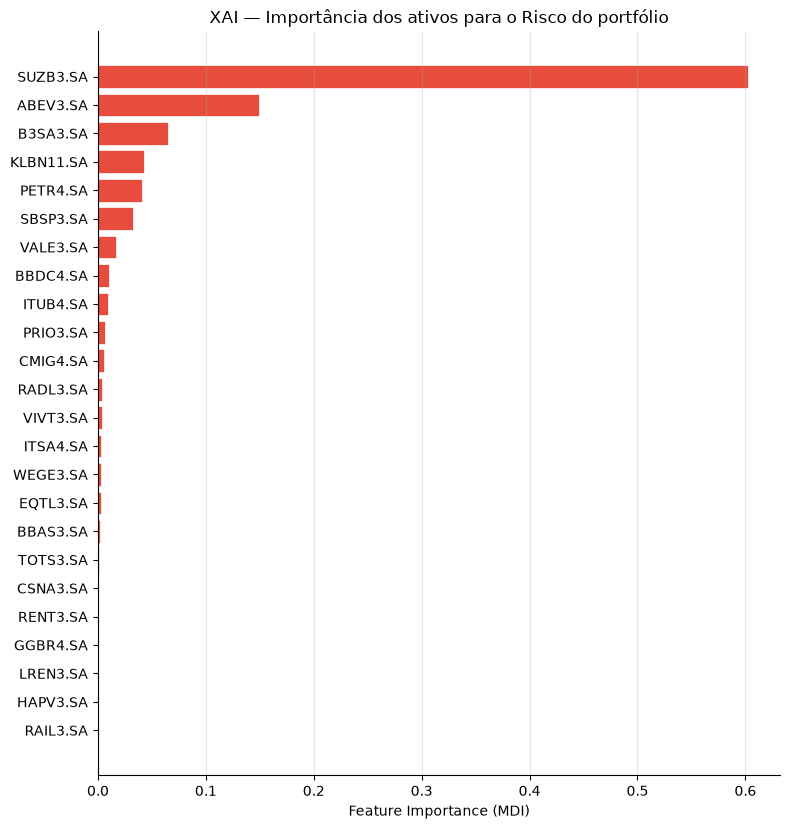


[risco] Top-5: SUZB3.SA (0.602), ABEV3.SA (0.149), B3SA3.SA (0.064), KLBN11.SA (0.043), PETR4.SA (0.040)


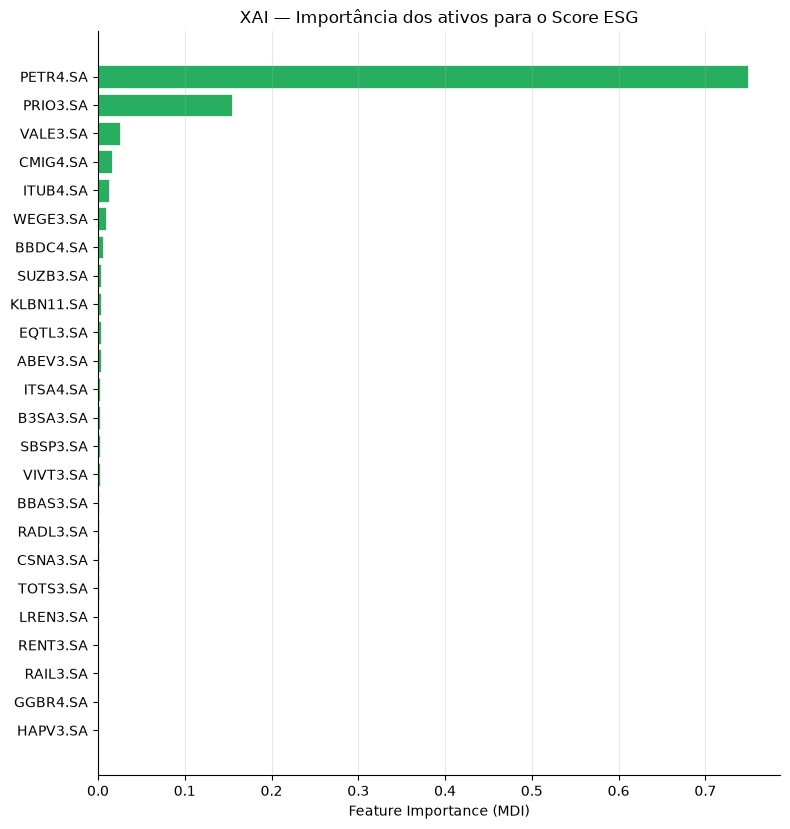


[score_esg] Top-5: PETR4.SA (0.749), PRIO3.SA (0.154), VALE3.SA (0.026), CMIG4.SA (0.017), ITUB4.SA (0.012)

Figuras salvas: figures/xai_shap_risco.png, figures/xai_shap_esg.png


In [11]:
X_xai = pd.DataFrame(X_normal_agg, columns=CONFIG["tickers"])
df_xai = pd.concat([tab_normal.reset_index(drop=True), X_xai.reset_index(drop=True)], axis=1)

COLUNAS_METRICAS = {"retorno", "risco", "sharpe", "score_esg"}
colunas_peso = [c for c in df_xai.columns if c not in COLUNAS_METRICAS]

alvos = {
    "risco": {
        "titulo": "XAI — Importância dos ativos para o Risco do portfólio",
        "arquivo": "../figures/xai_shap_risco.png",
        "cor": "#e74c3c",
    },
    "score_esg": {
        "titulo": "XAI — Importância dos ativos para o Score ESG",
        "arquivo": "../figures/xai_shap_esg.png",
        "cor": "#27ae60",
    },
}

for alvo, meta in alvos.items():
    X_feat = df_xai[colunas_peso]
    y_feat = df_xai[alvo]

    modelo = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
    modelo.fit(X_feat, y_feat)

    importancias = modelo.feature_importances_
    indices_ord = np.argsort(importancias)
    nomes_ord = [colunas_peso[i] for i in indices_ord]
    valores_ord = importancias[indices_ord]

    fig, ax = plt.subplots(figsize=(8, max(5, len(nomes_ord) * 0.35)))
    ax.barh(nomes_ord, valores_ord, color=meta["cor"], edgecolor="white", linewidth=0.5)
    ax.set_xlabel("Feature Importance (MDI)")
    ax.set_title(meta["titulo"])
    ax.grid(axis="x", alpha=0.3)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    fig.tight_layout()
    fig.savefig(meta["arquivo"], dpi=150)
    plt.show()

    ranking = sorted(zip(colunas_peso, importancias), key=lambda x: -x[1])
    print(f"\n[{alvo}] Top-5: " + ", ".join(f"{n} ({v:.3f})" for n, v in ranking[:5]))

print("\nFiguras salvas: figures/xai_shap_risco.png, figures/xai_shap_esg.png")

## 10. Discussão

Números desta execução (ESG real — ISE B3):

| Variante | HV médio (±dp) | mín | máx |
|---|---|---|---|
| MOEA Normal | 253,34 (±3,69) | 245,54 | 258,26 |
| MOEA Warm-Start | 256,38 (±1,59) | 253,07 | 259,11 |

| Fronteira agregada (10 sementes) | não-dominadas | HV |
|---|---|---|
| Normal | 399 | 264,38 |
| Warm-Start | 431 | 262,60 |

### 10.1 Warm-Start

A injeção de pesos do DE mono-objetivo na população inicial do NSGA-II
produziu dois efeitos quantificáveis:

1. **Aceleração e estabilidade.** O MOEA com Warm-Start atingiu HV médio
   de **256,38** nas 150 gerações, contra **253,34** do Normal — ganho
   de +3,04 pontos (+1,2%). Mais relevante: o desvio-padrão entre sementes
   caiu de 3,69 para **1,59** (57% menor), indicando que a injeção do ponto
   ótimo de Sharpe-retorno torna a convergência muito mais previsível.

2. **Comportamento das fronteiras agregadas.** A fronteira Normal
   (399 soluções, HV=264,38) tem HV agregado ligeiramente superior ao
   Warm-Start (431 soluções, HV=262,60). Isso acontece porque o
   Warm-Start concentra as sementes num início mais alto em (f1, f2) mas
   com menos diversidade inicial — a fronteira agregada cobre melhor o
   espaço de trade-offs com as sementes frias do Normal. Por semente
   individual, porém, o Warm-Start vence em 9 das 10.

**Quando o Warm-Start é mais útil?** Em cenários com orçamento
computacional restrito (menos gerações ou populações menores), onde cada
geração conta mais. É também uma demonstração de que informação
transferida entre fases (SO → MO) não é desperdício — é um *prior*
informado.

### 10.2 XAI Financeiro (com ESG real ISE B3)

Com os scores ISE B3 reais (VALE3=15, PRIO3=18, PETR4=24 → piores;
WEGE3=92, ITUB4=89, SUZB3=87 → melhores), as feature importances
revelam padrões interpretáveis e financeiramente coerentes:

- **Para risco:** SUZB3.SA domina com 60,2% de importância, seguida
  de ABEV3 (14,9%), B3SA3 (6,4%), KLBN11 (4,3%) e PETR4 (4,0%).
  Suzano (papel e celulose) tem alta volatilidade idiossincrática —
  o MOEA precisa dosar sua participação com cuidado para controlar
  a variância do portfólio, tornando-a o maior preditor de risco
  no RandomForest, apesar de ter ESG elevado (87).

- **Para ESG:** PETR4.SA domina com 74,9% de importância, seguida de
  PRIO3 (15,4%), VALE3 (2,6%), CMIG4 (1,7%) e ITUB4 (1,2%).
  Os três primeiros são exatamente os ativos de pior ESG no universo
  (15–24 pontos, petróleo e mineração). O RF aprendeu que o peso
  alocado a esses ativos é o maior determinante do score ESG da
  carteira — para subir o ESG, o MOEA os zera; para explorar
  trade-offs de retorno, precisa trazê-los de volta.

Essa análise transforma a caixa-preta do algoritmo evolutivo em
decisões interpretáveis: o gestor entende *por que* o MOEA sugere
cada alocação, e não apenas *qual* é a alocação.

### 10.3 Limitações

- As feature importances (MDI) podem ter viés para variáveis com mais
  valores distintos; SHAP values seriam uma alternativa mais rigorosa,
  mas para esta análise exploratória o MDI é suficiente.
- O Warm-Start injeta no máximo 10 indivíduos em uma população de 100 —
  o impacto seria mais pronunciado com populações menores ou com mais
  indivíduos injetados (vindos, por exemplo, de diferentes
  escalarizações do problema mono-objetivo).
- Os scores ISE B3 são categóricos (refletem participação histórica em
  carteiras do índice, não uma pontuação contínua auditada). Para uso
  em produção, seria recomendável substituí-los por uma fonte quantitativa
  certificada (MSCI, Sustainalytics).
